---

### NOTEBOOK 02 : ISOLATION FOREST - DÉTECTION D'ANOMALIES

---

---

## Description

    Ce notebook constitue le livrable de la phase de modélisation du projet.
    Il est consacré à l'application de l'algorithme Isolation Forest pour
    la détection d'anomalies dans les transactions bancaires.

    OBJECTIFS:
    ----------
        - Entraîner un modèle Isolation Forest sur les données nettoyées
        - Détecter les transactions anormales
        - Analyser et visualiser les résultats
        - Interpréter les anomalies détectées
        - Sauvegarder le modèle pour une utilisation ultérieure

    CONTENU:
    --------
        1. Introduction théorique à Isolation Forest
        2. Chargement et préparation des données
        3. Sélection des variables numériques
        4. Encodage des variables catégorielles
        5. Normalisation des données
        6. Entraînement du modèle Isolation Forest
        7. Évaluation et analyse des résultats
        8. Visualisation des anomalies
        9. Export des anomalies détectées
        10. Synthèse et recommandations

    PRÉREQUIS:
    ----------
        - Notebook 01 exécuté (données nettoyées disponibles)
        - Bibliothèques: pandas, numpy, matplotlib, seaborn, scikit-learn

---

### SECTION 1 : INTRODUCTION - RAPPEL THÉORIQUE

---

   #### 1.1. PRINCIPE DE L'ALGORITHME ISOLATION FOREST
   -----------------------------------------------
   Isolation Forest est un algorithme de détection d'anomalies basé sur le
   principe d'isolation. Contrairement aux méthodes traditionnelles qui
   modélisent les points normaux, Isolation Forest isole directement les
   anomalies.

   FONDEMENT THÉORIQUE :

      - Les anomalies sont rares et différentes
      - Elles sont plus faciles à isoler que les points normaux
      - L'algorithme construit des arbres de décision aléatoires
      - Les anomalies ont des chemins plus courts dans les arbres
      - Score d'anomalie inversement proportionnel à la longueur du chemin

   #### 1.2. AVANTAGES DE L'APPROCHE
   -----------------------------
      - Non supervisé: ne nécessite pas de données étiquetées
      - Adapté aux données déséquilibrées: efficace avec peu d'anomalies
      - Robuste: résiste aux outliers dans les données d'entraînement
      - Linéaire: complexité en O(n)
      - Interprétable: les scores sont facilement interprétables

   #### 1.3. HYPERPARAMÈTRES CLÉS
   --------------------------
      n_estimators: Nombre d'arbres dans la forêt (défaut: 100)
      contamination: Proportion attendue d'anomalies (défaut: 0.1)
      max_samples: Nombre d'échantillons par arbre (défaut: "auto")
      random_state: Graine aléatoire pour la reproductibilité
      bootstrap: Échantillonnage avec remise (défaut: False)

   #### 1.4. INTERPRÉTATION DES RÉSULTATS
   ----------------------------------
      - Score = -1: Anomalie détectée
      - Score = 1: Transaction normale
      - Score d'anomalie (anomaly_score): Plus le score est négatif,
         plus la transaction est anormale

---         

### SECTION 2 : IMPORTATION DES BIBLIOTHÈQUES

In [1]:
"""
2. IMPORTATION DES BIBLIOTHÈQUES
=================================

Cette section importe toutes les bibliothèques nécessaires pour:
    - La manipulation des données (pandas, numpy)
    - La visualisation (matplotlib, seaborn)
    - La modélisation (scikit-learn)
    - La gestion des fichiers (joblib, pathlib)
    - La gestion des avertissements (warnings)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import yaml
import sklearn  
from datetime import datetime
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configuration des warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Création des dossiers nécessaires
for folder in ['../models', '../results/figures', '../results/metrics']:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("="*60)
print("NOTEBOOK 02 : ISOLATION FOREST - DÉTECTION D'ANOMALIES")
print("="*60)

print("\nBibliothèques importées avec succès")
print(f"   - Pandas: {pd.__version__}")
print(f"   - NumPy: {np.__version__}")
print(f"   - Matplotlib: {plt.matplotlib.__version__}")
print(f"   - Seaborn: {sns.__version__}")
print(f"   - Scikit-learn: {sklearn.__version__}")  
print(f"   - Joblib: {joblib.__version__}")

NOTEBOOK 02 : ISOLATION FOREST - DÉTECTION D'ANOMALIES

Bibliothèques importées avec succès
   - Pandas: 3.0.3
   - NumPy: 2.5.0
   - Matplotlib: 3.11.0
   - Seaborn: 0.13.2
   - Scikit-learn: 1.9.0
   - Joblib: 1.5.3


### SECTION 3 : CHARGEMENT DES DONNÉES

In [2]:
"""
    Cette section charge le jeu de données nettoyé produit par le Notebook 01.
    Les données sont prêtes pour la modélisation.
"""

def load_cleaned_data(filepath: str) -> pd.DataFrame:
    """
    Charge le jeu de données nettoyé à partir d'un fichier CSV.
    
    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV contenant les données nettoyées
        
    Returns
    -------
    pd.DataFrame
        DataFrame contenant les données nettoyées
        
    Raises
    ------
    FileNotFoundError
        Si le fichier spécifié n'existe pas
        
    Examples
    --------
    >>> df = load_cleaned_data('../data/processed/indian_banking_transactions_clean.csv')
    >>> print(df.shape)
    (550000, 20)
    
    Notes
    -----
    Cette fonction suppose que les données ont déjà été nettoyées
    et sont prêtes pour la modélisation.
    """
    
    try:
        df = pd.read_csv(filepath)
        print(f"Données chargées avec succès")
        print(f"   - Fichier: {filepath}")
        print(f"   - Dimensions: {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
        return df
    except FileNotFoundError:
        print(f"Erreur: Fichier non trouvé à {filepath}")
        raise
    except Exception as e:
        print(f"Erreur lors du chargement: {str(e)}")
        raise

# Chargement des données
DATA_PATH = '../data/processed/indian_banking_transactions_clean.csv'

try:
    df = load_cleaned_data(DATA_PATH)
    print("\nAperçu des 5 premières lignes:")
    display(df.head())
except Exception as e:
    print(f"Erreur de chargement: {e}")
    df = pd.DataFrame()


Données chargées avec succès
   - Fichier: ../data/processed/indian_banking_transactions_clean.csv
   - Dimensions: 550,000 lignes x 20 colonnes

Aperçu des 5 premières lignes:


,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,Unknown,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,Unknown,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,Unknown,0.00,Success,API,Verified,0,14


### SECTION 4 : SÉLECTION DES VARIABLES POUR LA MODÉLISATION

#### SECTION 4.1 : SÉLECTION DES VARIABLES NUMÉRIQUES

In [3]:
"""
Cette section sélectionne les variables numériques qui seront utilisées
pour la détection d'anomalies.

VARIABLES SÉLECTIONNÉES:
    - transaction_amount: Montant de la transaction
    - account_balance: Solde du compte
    - credit_score: Score de crédit du client
    - has_loan: Présence d'un prêt (0/1)
    - emi_amount: Montant des mensualités
    - transaction_hour: Heure de la transaction

JUSTIFICATION DES CHOIX:
    - Variables quantitatives continues ou discrètes
    - Variables pertinentes pour la détection d'anomalies
    - Absence de valeurs manquantes significatives
    - Indépendance relative (corrélations faibles)
"""

def select_features(df: pd.DataFrame) -> tuple:
    """
    Sélectionne les variables numériques pour la modélisation.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant les données nettoyées
        
    Returns
    -------
    tuple
        - feature_names: Liste des noms des variables
        - categorical_features: Liste des noms des variables catégorielles
        
    Examples
    --------
    >>> numeric_features, categorical_features = select_features(df)
    >>> print(numeric_features)
    ['transaction_amount', 'account_balance', ...]
    """

    numeric_features = [
        'transaction_amount',
        'account_balance',
        'credit_score',
        'has_loan',
        'emi_amount',
        'transaction_hour'
    ]
    
    categorical_features = [
        'channel',
        'account_type',
        'transaction_type',
        'transaction_direction'
    ]
    
    # Vérifier la présence des colonnes
    all_features = numeric_features + categorical_features
    missing_cols = [col for col in all_features if col not in df.columns]
    if missing_cols:
        print(f"Colonnes manquantes: {missing_cols}")
        raise ValueError(f"Colonnes manquantes: {missing_cols}")
    
    print(f"\nMatrice de données:")
    print(f"   - Lignes: {df.shape[0]:,}")
    print(f"   - Variables numériques: {len(numeric_features)}")
    print(f"   - Variables catégorielles: {len(categorical_features)}")
    
    print("\nVariables numériques sélectionnées:")
    for i, feat in enumerate(numeric_features, 1):
        print(f"   {i}. {feat}")
    
    print("\nVariables catégorielles sélectionnées:")
    for i, feat in enumerate(categorical_features, 1):
        print(f"   {i}. {feat}")
    
    return numeric_features, categorical_features

numeric_features, categorical_features = select_features(df)


Matrice de données:
   - Lignes: 550,000
   - Variables numériques: 6
   - Variables catégorielles: 4

Variables numériques sélectionnées:
   1. transaction_amount
   2. account_balance
   3. credit_score
   4. has_loan
   5. emi_amount
   6. transaction_hour

Variables catégorielles sélectionnées:
   1. channel
   2. account_type
   3. transaction_type
   4. transaction_direction


#### SECTION 4.2 : ENCODAGE DES VARIABLES CATÉGORIELLES

In [4]:
"""
Cette section encode les variables catégorielles pour les rendre utilisables
par les algorithmes de machine learning.

VARIABLES CATÉGORIELLES ENCODÉES:
    - channel: Canal de transaction (Mobile_App, Web, ATM, etc.)
    - account_type: Type de compte (Savings, Current, Salary, etc.)
    - transaction_type: Type de transaction (UPI, NEFT, POS, etc.)
    - transaction_direction: Sens du flux (Debit, Credit)

MÉTHODE UTILISÉE: One-Hot Encoding
    - Transforme chaque catégorie en une colonne binaire (0 ou 1)
    - Évite de créer une relation d'ordre entre les catégories

JUSTIFICATION:
    - Les variables catégorielles apportent un contexte métier essentiel
    - Elles permettent au modèle de distinguer les profils de risque
    - Exemple: Une fraude sur Mobile_App n'a pas le même profil qu'une fraude sur Branch
"""

def encode_categorical_features(df: pd.DataFrame, numeric_features: list, categorical_features: list) -> tuple:
    """
    Encode les variables catégorielles avec One-Hot Encoding.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant les données nettoyées
    numeric_features : list
        Liste des noms des variables numériques
    categorical_features : list
        Liste des noms des variables catégorielles
        
    Returns
    -------
    tuple
        - X_encoded: Matrice numpy avec les variables encodées
        - feature_names: Liste des noms de toutes les variables
        - encoder: Objet OneHotEncoder ajusté
        
    Examples
    --------
    >>> X_encoded, feature_names, encoder = encode_categorical_features(df, numeric_features, categorical_features)
    >>> print(X_encoded.shape)
    (550000, 45)
    """
    
    print("\n" + "="*60)
    print("4.1. ENCODAGE DES VARIABLES CATÉGORIELLES")
    print("="*60)
    
    # Extraire les variables numériques
    X_numeric = df[numeric_features].values
    
    # Encoder les variables catégorielles
    print("\nApplication du One-Hot Encoding...")
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_categorical = encoder.fit_transform(df[categorical_features])
    
    # Récupérer les noms des colonnes encodées
    categorical_names = encoder.get_feature_names_out(categorical_features)
    
    # Combiner les variables
    X_encoded = np.hstack([X_numeric, X_categorical])
    all_feature_names = numeric_features + list(categorical_names)
    
    print(f"\nEncodage terminé!")
    print(f"   - Matrice X: {X_encoded.shape[0]:,} lignes x {X_encoded.shape[1]} colonnes")
    print(f"   - Variables numériques: {len(numeric_features)}")
    print(f"   - Variables catégorielles encodées: {len(categorical_names)}")
    print(f"   - Total variables: {X_encoded.shape[1]}")
    
    # Afficher quelques noms de colonnes encodées
    print(f"\nExemples de colonnes encodées:")
    for i, name in enumerate(categorical_names[:10], 1):
        print(f"      {i}. {name}")
    if len(categorical_names) > 10:
        print(f"      ... et {len(categorical_names) - 10} autres")
    
    # Sauvegarder l'encodeur
    joblib.dump(encoder, '../models/onehot_encoder.pkl')
    print("\nEncodeur sauvegardé: '../models/onehot_encoder.pkl'")
    
    return X_encoded, all_feature_names, encoder

X_encoded, feature_names, encoder = encode_categorical_features(df, numeric_features, categorical_features)


4.1. ENCODAGE DES VARIABLES CATÉGORIELLES

Application du One-Hot Encoding...

Encodage terminé!
   - Matrice X: 550,000 lignes x 29 colonnes
   - Variables numériques: 6
   - Variables catégorielles encodées: 23
   - Total variables: 29

Exemples de colonnes encodées:
      1. channel_API
      2. channel_ATM
      3. channel_Branch
      4. channel_Mobile_App
      5. channel_POS_Terminal
      6. channel_Web
      7. account_type_Current
      8. account_type_Fixed Deposit
      9. account_type_NRI
      10. account_type_Salary
      ... et 13 autres

Encodeur sauvegardé: '../models/onehot_encoder.pkl'


### SECTION 5 : NORMALISATION DES DONNÉES (STANDARD SCALER)

In [5]:
"""
Cette section applique une transformation logarithmique pour réduire
l'asymétrie des données avant la normalisation.

RAISON DE LA LOG-TRANSFORMATION:
    - Réduire l'asymétrie des distributions (skewness)
    - Stabiliser la variance
    - Réduire l'impact des valeurs extrêmes (outliers)
    - Améliorer la performance des algorithmes

VARIABLES TRANSFORMÉES:
    - transaction_amount: log(1 + amount)
    - account_balance: log(1 + balance)
    - emi_amount: log(1 + emi) (si présente)

MÉTHODE: np.log1p(x) = log(1 + x)
    - Évite les problèmes avec log(0)
    - Préserve l'ordre des valeurs
"""

def normalize_data(X: np.ndarray, numeric_features: list, df: pd.DataFrame) -> tuple:
    """
    Applique une transformation logarithmique sur les montants/soldes 
    puis normalise les données en utilisant StandardScaler.
    
    Parameters
    ----------
    X : np.ndarray
        Matrice des données encodées
    numeric_features : list
        Liste des noms des variables numériques
    df : pd.DataFrame
        DataFrame original
        
    Returns
    -------
    tuple
        - X_scaled: Array numpy des données transformées et normalisées
        - scaler: Objet StandardScaler ajusté
        
    Notes
    -----
    La transformation log1p est appliquée sur:
        - transaction_amount
        - account_balance
        - emi_amount (si présente)
        
    Examples
    --------
    >>> X_scaled, scaler = normalize_data(X_encoded, numeric_features, df)
    >>> print(X_scaled.mean())
    0.0
    """
    
    print("\n" + "="*60)
    print("5. TRANSFORMATION LOG + NORMALISATION")
    print("="*60)
    
    # Copie pour éviter de modifier l'original
    X_transformed = X.copy()
    
    # Variables à transformer par log1p
    log_vars = ['transaction_amount', 'account_balance']
    if 'emi_amount' in df.columns:
        log_vars.append('emi_amount')
    
    # Trouver les indices des colonnes à transformer
    log_indices = []
    for i, feat in enumerate(numeric_features):
        if feat in log_vars:
            log_indices.append(i)
    
    print("\nVariables transformées par log1p:")
    for feat in log_vars:
        print(f"   - {feat}")
    
    # Application de la transformation log1p
    for idx in log_indices:
        X_transformed[:, idx] = np.log1p(X_transformed[:, idx])
    
    # Statistiques avant normalisation
    print("\nStatistiques après transformation log1p:")
    for idx, feat in zip(log_indices, log_vars):
        print(f"   - {feat}: min={X_transformed[:, idx].min():.4f}, "
              f"max={X_transformed[:, idx].max():.4f}, "
              f"mean={X_transformed[:, idx].mean():.4f}")
    
    # Normalisation StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_transformed)
    
    print("\nStatistiques après StandardScaler:")
    print(f"   - Moyenne globale: {X_scaled.mean():.6f}")
    print(f"   - Écart-type global: {X_scaled.std():.6f}")
    
    # Sauvegarder le scaler
    joblib.dump(scaler, '../models/scaler.pkl')
    print("\nScaler sauvegardé: '../models/scaler.pkl'")
    
    return X_scaled, scaler

X_scaled, scaler = normalize_data(X_encoded, numeric_features, df)


5. TRANSFORMATION LOG + NORMALISATION

Variables transformées par log1p:
   - transaction_amount
   - account_balance
   - emi_amount

Statistiques après transformation log1p:
   - transaction_amount: min=1.2238, max=16.1181, mean=7.9744
   - account_balance: min=6.2166, max=15.4249, mean=10.5024
   - emi_amount: min=0.0000, max=11.9403, mean=2.9717

Statistiques après StandardScaler:
   - Moyenne globale: 0.000000
   - Écart-type global: 1.000000

Scaler sauvegardé: '../models/scaler.pkl'


### SECTION 6 : CONFIGURATION DU MODÈLE ISOLATION FOREST

In [6]:
"""
Cette section définit la configuration du modèle Isolation Forest.

HYPERPARAMÈTRES:
    - n_estimators: 100 (nombre d'arbres)
    - contamination: 0.01 (1% d'anomalies attendues)
    - max_samples: "auto" (utilisation de tous les échantillons)
    - random_state: 42 (reproductibilité)
    - bootstrap: False

JUSTIFICATION DES CHOIX:
    - contamination = 0.01: basé sur le taux de fraude réel (1%)
    - n_estimators = 100: bon compromis performance/précision
    - random_state = 42: reproductibilité des résultats
"""

def load_config(config_path: str = '../configs/config.yml') -> dict:
    """
    Charge la configuration du modèle à partir d'un fichier YAML.
    
    Parameters
    ----------
    config_path : str
        Chemin vers le fichier de configuration
        
    Returns
    -------
    dict
        Dictionnaire contenant les paramètres de configuration
        
    Examples
    --------
    >>> config = load_config()
    >>> print(config['isolation_forest']['contamination'])
    0.01
    """
    
    try:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        print("Configuration chargée avec succès")
        return config
    except FileNotFoundError:
        print(f"Fichier de configuration non trouvé: {config_path}")
        print("Utilisation des paramètres par défaut")
        return {
            'isolation_forest': {
                'n_estimators': 100,
                'contamination': 0.01,
                'max_samples': 'auto',
                'random_state': 42,
                'bootstrap': False
            }
        }

config = load_config()
if_config = config.get('isolation_forest', {})

print("\nParamètres du modèle:")
for key, value in if_config.items():
    print(f"   - {key}: {value}")

Configuration chargée avec succès

Paramètres du modèle:
   - n_estimators: 100
   - contamination: 0.01
   - max_samples: auto
   - random_state: 42
   - bootstrap: False


### SECTION 7: ENTRAÎNEMENT DU MODÈLE

In [7]:
"""
Cette section entraîne le modèle Isolation Forest sur les données normalisées.

ÉTAPES:
    1. Création du modèle avec les paramètres configurés
    2. Entraînement sur les données normalisées
    3. Prédiction des anomalies
    4. Sauvegarde du modèle
"""

def train_isolation_forest(X_scaled: np.ndarray, config: dict) -> tuple:
    """
    Entraîne le modèle Isolation Forest.
    
    Parameters
    ----------
    X_scaled : np.ndarray
        Données normalisées (numériques + catégorielles encodées)
    config : dict
        Configuration du modèle
        
    Returns
    -------
    tuple
        - model: Modèle Isolation Forest entraîné
        - predictions: Prédictions (-1 = anomalie, 1 = normal)
        - scores: Scores d'anomalie
        
    Examples
    --------
    >>> model, predictions, scores = train_isolation_forest(X_scaled, config)
    >>> print(np.sum(predictions == -1))
    5500
    """
    
    print("\n" + "="*60)
    print("7. ENTRAÎNEMENT DU MODÈLE ISOLATION FOREST")
    print("="*60)
    
    # Création du modèle
    model = IsolationForest(
        n_estimators=config.get('n_estimators', 100),
        contamination=config.get('contamination', 0.01),
        max_samples=config.get('max_samples', 'auto'),
        random_state=config.get('random_state', 42),
        bootstrap=config.get('bootstrap', False)
    )
    
    print("\nEntraînement du modèle...")
    model.fit(X_scaled)
    
    # Prédictions
    predictions = model.predict(X_scaled)
    scores = model.decision_function(X_scaled)
    
    # Statistiques
    n_anomalies = np.sum(predictions == -1)
    pct_anomalies = n_anomalies / len(predictions) * 100
    
    print(f"\nRésultats de la détection:")
    print(f"   - Transactions normales: {np.sum(predictions == 1):,}")
    print(f"   - Anomalies détectées: {n_anomalies:,} ({pct_anomalies:.2f}%)")
    
    # Sauvegarde du modèle
    joblib.dump(model, '../models/isolation_forest.pkl')
    print("\nModèle sauvegardé: '../models/isolation_forest.pkl'")
    
    return model, predictions, scores

model, predictions, scores = train_isolation_forest(X_scaled, if_config)


7. ENTRAÎNEMENT DU MODÈLE ISOLATION FOREST

Entraînement du modèle...

Résultats de la détection:
   - Transactions normales: 544,500
   - Anomalies détectées: 5,500 (1.00%)

Modèle sauvegardé: '../models/isolation_forest.pkl'


### SECTION 8 : ANALYSE DES RÉSULTATS

In [8]:
"""
Cette section analyse les résultats du modèle Isolation Forest.

INDICATEURS ANALYSÉS:
    - Nombre d'anomalies détectées
    - Proportion d'anomalies par rapport au total
    - Distribution des scores d'anomalie
    - Statistiques des variables pour les anomalies vs normales
"""

def analyze_results(df: pd.DataFrame, predictions: np.ndarray, scores: np.ndarray) -> None:
    """
    Analyse les résultats du modèle Isolation Forest.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame original
    predictions : np.ndarray
        Prédictions du modèle (-1 = anomalie, 1 = normal)
    scores : np.ndarray
        Scores d'anomalie
        
    Returns
    -------
    None
        Les résultats sont affichés et sauvegardés.
        
    Examples
    --------
    >>> analyze_results(df, predictions, scores)
    """
    
    print("\n" + "="*60)
    print("8. ANALYSE DES RÉSULTATS")
    print("="*60)
    
    # Ajouter les prédictions au DataFrame
    df_result = df.copy()
    df_result['if_anomaly'] = predictions
    df_result['if_score'] = scores
    
    # Séparer normales et anomalies
    normal = df_result[df_result['if_anomaly'] == 1]
    anomalies = df_result[df_result['if_anomaly'] == -1]
    
    print("\n8.1 STATISTIQUES GLOBALES:")
    print("-"*40)
    print(f"   - Total: {len(df_result):,}")
    print(f"   - Normales: {len(normal):,} ({len(normal)/len(df_result)*100:.2f}%)")
    print(f"   - Anomalies: {len(anomalies):,} ({len(anomalies)/len(df_result)*100:.2f}%)")
    
    print("\n8.2 STATISTIQUES DES VARIABLES (ANOMALIES VS NORMALES):")
    print("-"*40)
    
    variables = ['transaction_amount', 'account_balance', 'credit_score', 'has_loan', 'emi_amount', 'transaction_hour']
    
    stats = []
    for var in variables:
        stats.append({
            'Variable': var,
            'Moyenne_Normal': normal[var].mean(),
            'Moyenne_Anomalie': anomalies[var].mean(),
            'Écart_Normal': normal[var].std(),
            'Écart_Anomalie': anomalies[var].std()
        })
    
    stats_df = pd.DataFrame(stats)
    display(stats_df.round(2))
    
    # Sauvegarde
    stats_df.to_csv('../results/metrics/isolation_forest_stats.csv', index=False)
    print("\nStatistiques sauvegardées: '../results/metrics/isolation_forest_stats.csv'")
    
    return df_result

df_result = analyze_results(df, predictions, scores)


8. ANALYSE DES RÉSULTATS

8.1 STATISTIQUES GLOBALES:
----------------------------------------
   - Total: 550,000
   - Normales: 544,500 (99.00%)
   - Anomalies: 5,500 (1.00%)

8.2 STATISTIQUES DES VARIABLES (ANOMALIES VS NORMALES):
----------------------------------------


,Variable,Moyenne_Normal,Moyenne_Anomalie,Écart_Normal,Écart_Anomalie
0,transaction_amount,28597.28,159578.58,134972.53,358602.31
1,account_balance,84104.91,128625.34,169490.80,274308.32
2,credit_score,599.90,591.06,172.82,194.72
3,has_loan,0.34,0.86,0.48,0.35
4,emi_amount,2321.31,6775.84,4924.43,7295.92
5,transaction_hour,11.49,12.84,6.92,7.43



Statistiques sauvegardées: '../results/metrics/isolation_forest_stats.csv'


### SECTION 9 : VISUALISATION DES RÉSULTATS


9. VISUALISATION DES RÉSULTATS

9.1 DISTRIBUTION DES SCORES D'ANOMALIE:
----------------------------------------


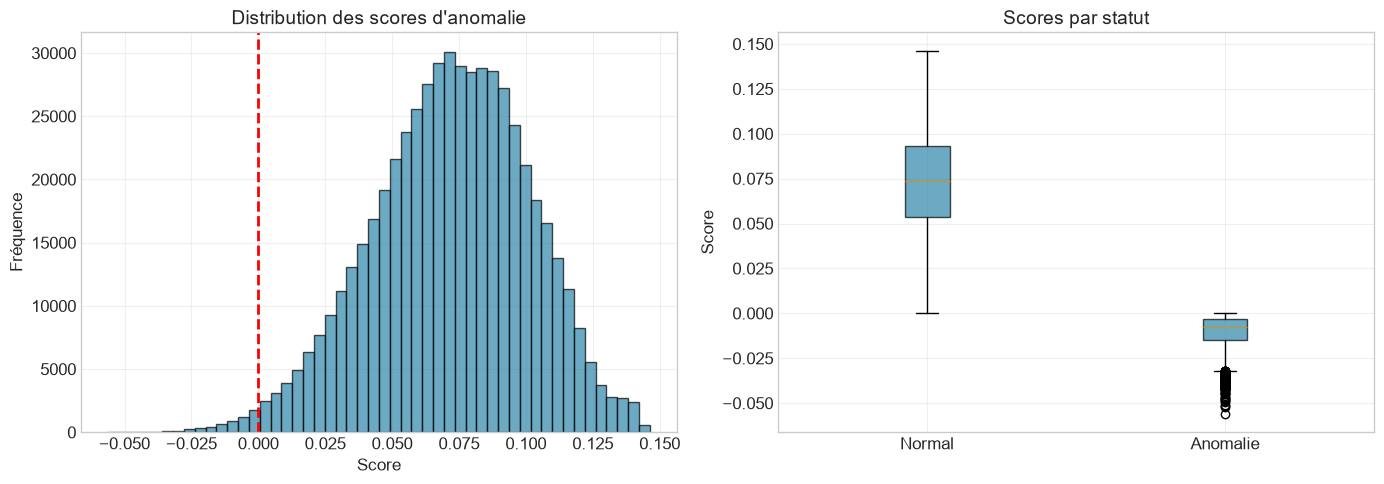

Graphique sauvegardé: '../results/figures/if_scores_distribution.png'

9.2 VISUALISATION ACP DES ANOMALIES:
----------------------------------------
   - Nombre de variables utilisées: 29
   - Variance expliquée PC1: 8.4%
   - Variance expliquée PC2: 6.9%
   - Variance totale expliquée: 15.2%


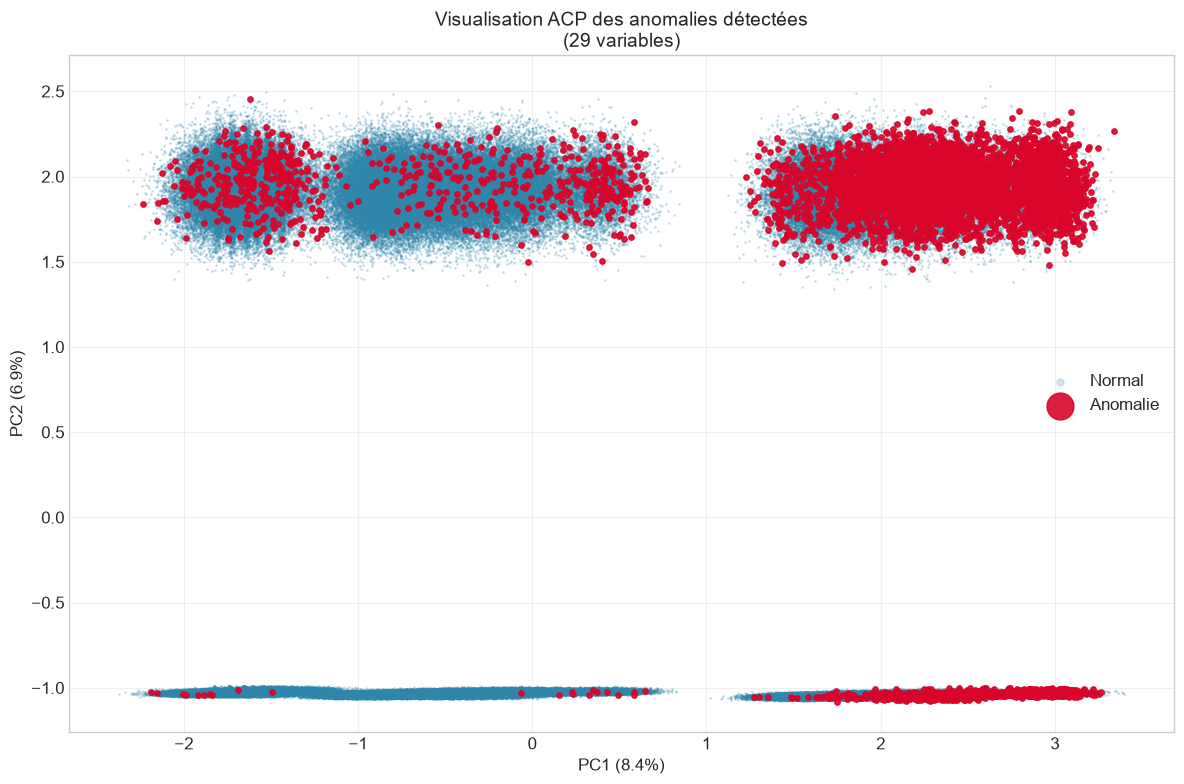

Graphique sauvegardé: '../results/figures/if_pca_visualization.png'

9.3 COMPARAISON DES VARIABLES (ANOMALIES VS NORMALES):
----------------------------------------


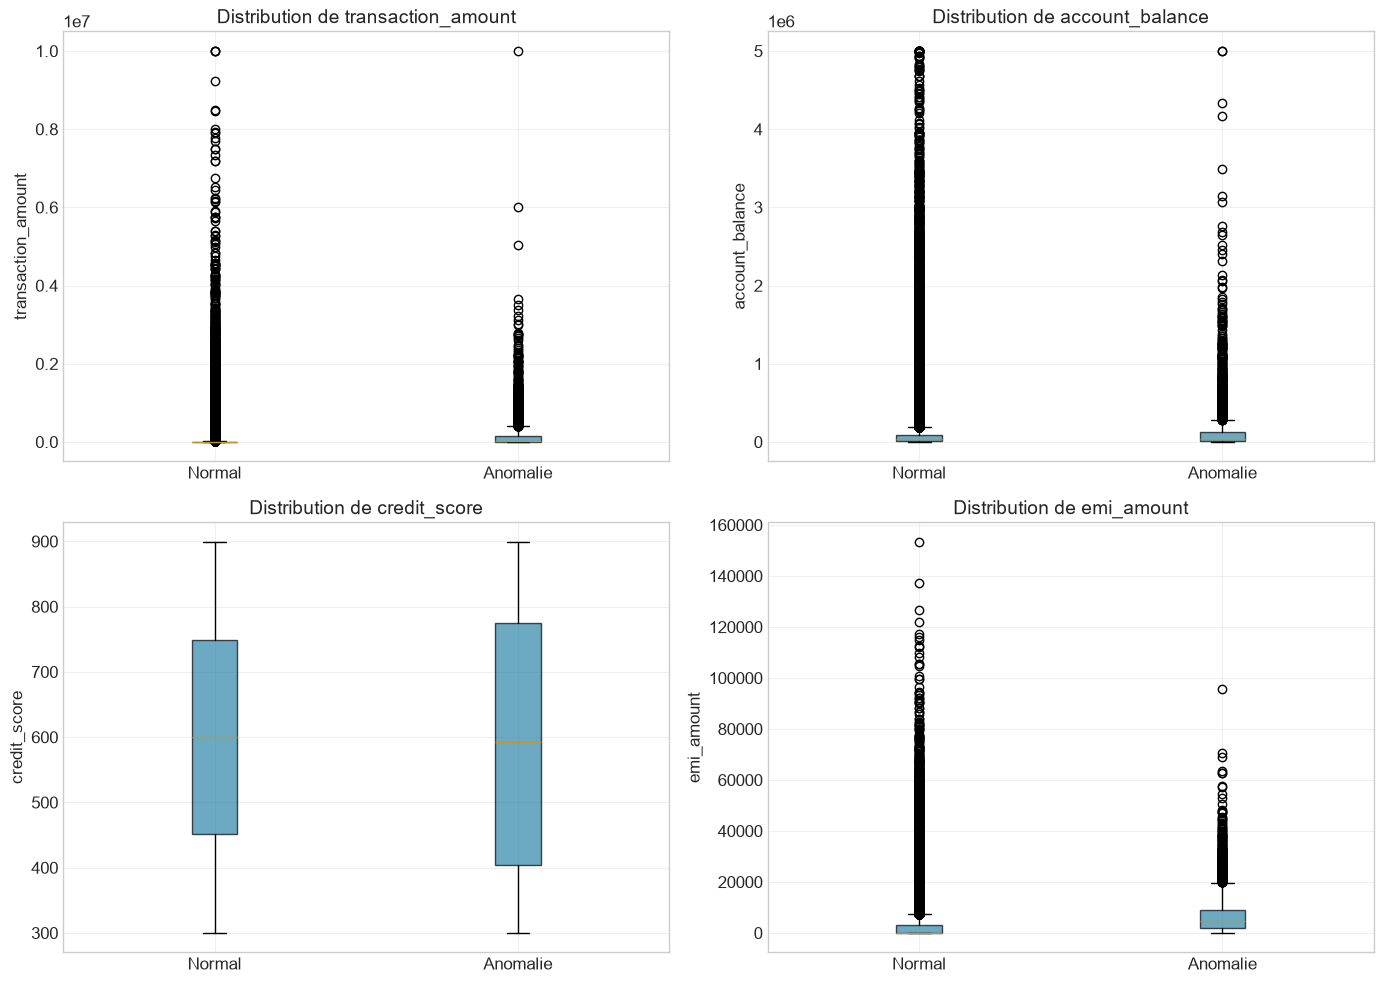

Graphique sauvegardé: '../results/figures/if_variable_comparison.png'

9.4 ANALYSE DE LA DISTRIBUTION HORAIRE (COURBES DE DENSITÉ):
----------------------------------------


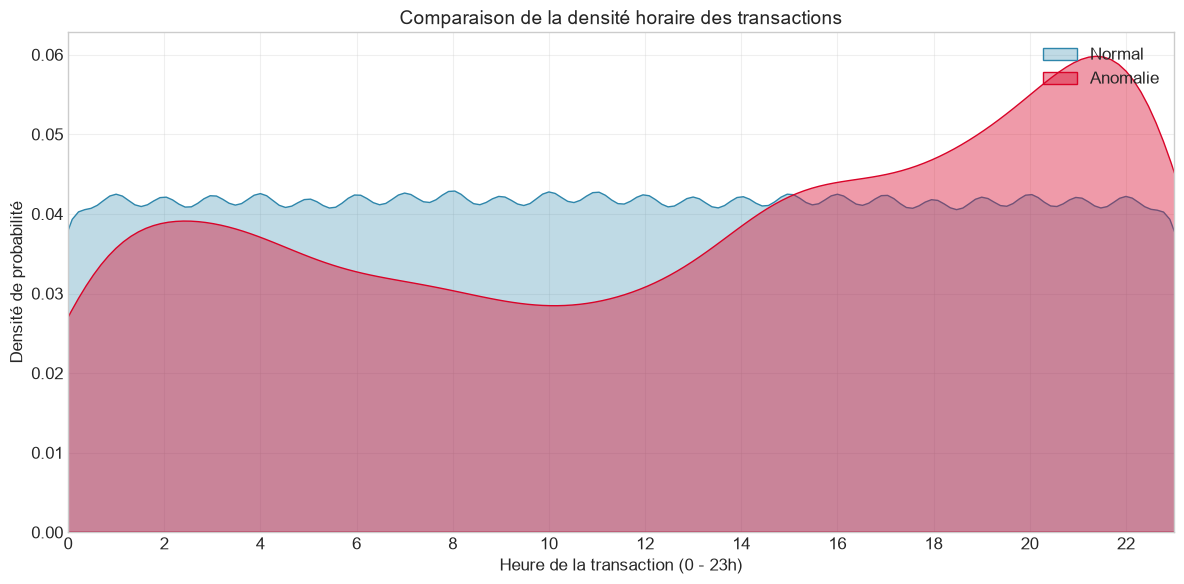

Graphique sauvegardé: '../results/figures/if_hourly_density_comparison.png'


In [12]:
"""
Cette section produit des visualisations pour interpréter les résultats
du modèle Isolation Forest.

GRAPHIQUES PRODUITS:
    1. Distribution des scores d'anomalie
    2. Visualisation ACP des anomalies
    3. Comparaison des variables (anomalies vs normales)
    4. Analyse de la distribution horaire (courbes de densité)
"""

def visualize_results(df_result: pd.DataFrame, X_scaled: np.ndarray) -> None:
    """
    Visualise les résultats du modèle Isolation Forest.
    
    Parameters
    ----------
    df_result : pd.DataFrame
        DataFrame avec les prédictions
    X_scaled : np.ndarray
        Données normalisées
        
    Returns
    -------
    None
        Les graphiques sont affichés et sauvegardés.
        
    Notes
    -----
    Cette fonction produit 4 visualisations:
        1. Distribution des scores d'anomalie
        2. Visualisation ACP des anomalies
        3. Comparaison des variables (boxplots)
        4. Analyse de la distribution horaire (KDE)
        
    Examples
    --------
    >>> visualize_results(df_result, X_scaled)
    """
    
    print("\n" + "="*60)
    print("9. VISUALISATION DES RÉSULTATS")
    print("="*60)
    
    # Créer le dossier
    Path('../results/figures').mkdir(parents=True, exist_ok=True)
    
    # =============================================================
    # 9.1. Distribution des scores
    # =============================================================
    
    """
    9.1. DISTRIBUTION DES SCORES D'ANOMALIE
    ---------------------------------------
    Ce graphique montre la distribution des scores d'anomalie attribués
    à chaque transaction par le modèle Isolation Forest.
    
    INTERPRÉTATION:
        - Les scores négatifs indiquent des anomalies
        - Les scores positifs indiquent des transactions normales
        - La ligne rouge représente le seuil de contamination
        - Plus le score est négatif, plus la transaction est anormale
    """
    
    print("\n9.1 DISTRIBUTION DES SCORES D'ANOMALIE:")
    print("-"*40)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogramme des scores
    ax1 = axes[0]
    ax1.hist(df_result['if_score'], bins=50, alpha=0.7, color='#2E86AB', edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax1.set_title('Distribution des scores d\'anomalie')
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Fréquence')
    ax1.grid(True, alpha=0.3)
    
    # Boxplot des scores par statut
    ax2 = axes[1]
    data_scores = [df_result[df_result['if_anomaly'] == 1]['if_score'],
                   df_result[df_result['if_anomaly'] == -1]['if_score']]
    bp1 = ax2.boxplot(data_scores, patch_artist=True, tick_labels=['Normal', 'Anomalie'])
    for patch in bp1['boxes']:
        patch.set_facecolor('#2E86AB')
        patch.set_alpha(0.7)
    ax2.set_title('Scores par statut')
    ax2.set_ylabel('Score')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/figures/if_scores_distribution.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Graphique sauvegardé: '../results/figures/if_scores_distribution.png'")
    
    # =============================================================
    # 9.2. Visualisation ACP
    # =============================================================
    
    """
    9.2. VISUALISATION ACP DES ANOMALIES
    ------------------------------------
    Ce graphique projette les transactions dans un espace à deux dimensions
    après réduction de dimension par ACP.
    
    INTERPRÉTATION:
        - Les points bleus représentent les transactions normales
        - Les points rouges représentent les anomalies détectées
        - Plus les anomalies sont isolées, meilleure est la détection
    """
    
    print("\n9.2 VISUALISATION ACP DES ANOMALIES:")
    print("-"*40)
    
    # Réduction de dimension
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Afficher les statistiques de l'ACP
    print(f"   - Nombre de variables utilisées: {X_scaled.shape[1]}")
    print(f"   - Variance expliquée PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
    print(f"   - Variance expliquée PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
    print(f"   - Variance totale expliquée: {pca.explained_variance_ratio_.sum()*100:.1f}%")
    
    # Création du graphique
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Points normaux (bleu, transparents, petits)
    mask_normal = df_result['if_anomaly'] == 1
    ax.scatter(X_pca[mask_normal, 0], X_pca[mask_normal, 1],
               c='#2E86AB', alpha=0.2, s=1, label='Normal')
    
    # Points anomalies (rouge, opaques, grands)
    mask_anomalie = df_result['if_anomaly'] == -1
    ax.scatter(X_pca[mask_anomalie, 0], X_pca[mask_anomalie, 1],
               c='#D90429', alpha=0.9, s=15, label='Anomalie')
    
    ax.set_title(f'Visualisation ACP des anomalies détectées\n({X_scaled.shape[1]} variables)', fontsize=14)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(markerscale=5)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/figures/if_pca_visualization.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Graphique sauvegardé: '../results/figures/if_pca_visualization.png'")
    
    # =============================================================
    # 9.3. Comparaison des variables
    # =============================================================
    
    """
    9.3. COMPARAISON DES VARIABLES (ANOMALIES VS NORMALES)
    -------------------------------------------------------
    Ces boxplots comparent la distribution des variables principales
    entre les transactions normales et les anomalies.
    
    INTERPRÉTATION:
        - Chaque paire de boxplots compare une variable
        - Une différence marquée indique que la variable discrimine bien
    """
    
    print("\n9.3 COMPARAISON DES VARIABLES (ANOMALIES VS NORMALES):")
    print("-"*40)
    
    variables = ['transaction_amount', 'account_balance', 'credit_score', 'emi_amount']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, var in enumerate(variables):
        ax = axes[i]
        data_var = [df_result[df_result['if_anomaly'] == 1][var],
                    df_result[df_result['if_anomaly'] == -1][var]]
        bp2 = ax.boxplot(data_var, patch_artist=True, tick_labels=['Normal', 'Anomalie'])
        for patch in bp2['boxes']:
            patch.set_facecolor('#2E86AB')
            patch.set_alpha(0.7)
        ax.set_title(f'Distribution de {var}')
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/figures/if_variable_comparison.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Graphique sauvegardé: '../results/figures/if_variable_comparison.png'")

    # =============================================================
    # 9.4. Analyse temporelle (KDE)
    # =============================================================
    
    """
    9.4. ANALYSE DE LA DISTRIBUTION HORAIRE (COURBES DE DENSITÉ)
    -------------------------------------------------------------
    Ce graphique compare les profils horaires des transactions normales
    et des anomalies à l'aide de courbes de densité (KDE).
    
    INTERPRÉTATION:
        - La courbe bleue représente la densité des transactions normales
        - La courbe rouge représente la densité des anomalies
        - Des courbes superposées indiquent que l'heure n'est pas discriminante
    """
    
    print("\n9.4 ANALYSE DE LA DISTRIBUTION HORAIRE (COURBES DE DENSITÉ):")
    print("-"*40)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Courbe KDE pour les normales
    sns.kdeplot(data=df_result[df_result['if_anomaly'] == 1], x='transaction_hour', 
                label='Normal', color='#2E86AB', fill=True, alpha=0.3, ax=ax)
    
    # Courbe KDE pour les anomalies
    sns.kdeplot(data=df_result[df_result['if_anomaly'] == -1], x='transaction_hour', 
                label='Anomalie', color='#D90429', fill=True, alpha=0.4, ax=ax)
    
    ax.set_title('Comparaison de la densité horaire des transactions')
    ax.set_xlabel('Heure de la transaction (0 - 23h)')
    ax.set_ylabel('Densité de probabilité')
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/figures/if_hourly_density_comparison.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Graphique sauvegardé: '../results/figures/if_hourly_density_comparison.png'")

# ===================================================================
# EXÉCUTION DE LA FONCTION
# ===================================================================

visualize_results(df_result, X_scaled)

### SECTION 10 : EXPORT DES ANOMALIES DÉTECTÉES

In [10]:
"""
Cette section exporte les anomalies détectées pour analyse ultérieure.

FICHIERS EXPORTÉS:
    - detected_anomalies_if.csv: Toutes les anomalies détectées
"""

def export_anomalies(df_result: pd.DataFrame) -> None:
    """
    Exporte les anomalies détectées dans des fichiers CSV.
    
    Parameters
    ----------
    df_result : pd.DataFrame
        DataFrame avec les prédictions
        
    Returns
    -------
    None
        Les fichiers sont sauvegardés dans le dossier results/anomalies/
        
    Examples
    --------
    >>> export_anomalies(df_result)
    """
    
    print("\n" + "="*60)
    print("10. EXPORT DES ANOMALIES DÉTECTÉES")
    print("="*60)
    
    # Créer le dossier
    Path('../results/anomalies').mkdir(parents=True, exist_ok=True)
    
    # Extraire les anomalies
    anomalies = df_result[df_result['if_anomaly'] == -1]
    anomalies.to_csv('../results/anomalies/detected_anomalies_if.csv', index=False)
    print(f"Anomalies exportées: {len(anomalies):,}")
    print("   - '../results/anomalies/detected_anomalies_if.csv'")
    
    # Créer un résumé des anomalies
    summary = anomalies.describe()
    summary.to_csv('../results/metrics/anomalies_summary.csv')
    print("   - '../results/metrics/anomalies_summary.csv'")

export_anomalies(df_result)


10. EXPORT DES ANOMALIES DÉTECTÉES
Anomalies exportées: 5,500
   - '../results/anomalies/detected_anomalies_if.csv'
   - '../results/metrics/anomalies_summary.csv'


### SECTION 11 : SYNTHÈSE ET RECOMMANDATIONS

In [11]:
"""
Cette section résume les résultats et formule des recommandations.

PRINCIPAUX RÉSULTATS:
    - Nombre d'anomalies détectées
    - Proportion par rapport au total
    - Caractéristiques des anomalies

RECOMMANDATIONS:
    - Validation des anomalies avec des experts métier
    - Ajustement du seuil de contamination si nécessaire
    - Combinaison avec DBSCAN pour validation croisée
"""

def generate_summary(df_result: pd.DataFrame) -> None:
    """
    Génère une synthèse des résultats du modèle Isolation Forest.
    
    Parameters
    ----------
    df_result : pd.DataFrame
        DataFrame avec les prédictions
        
    Returns
    -------
    None
        La synthèse est affichée et sauvegardée.
        
    Examples
    --------
    >>> generate_summary(df_result)
    """
    
    print("\n" + "="*60)
    print("11. SYNTHÈSE ET RECOMMANDATIONS")
    print("="*60)
    
    n_anomalies = np.sum(df_result['if_anomaly'] == -1)
    pct_anomalies = n_anomalies / len(df_result) * 100
    
    print("\n11.1 PRINCIPAUX RÉSULTATS:")
    print("-"*40)
    print(f"   - Total des transactions: {len(df_result):,}")
    print(f"   - Anomalies détectées: {n_anomalies:,} ({pct_anomalies:.2f}%)")
    print(f"   - Transactions normales: {len(df_result) - n_anomalies:,}")
    
    print("\n11.2 CARACTÉRISTIQUES DES ANOMALIES:")
    print("-"*40)
    
    anomalies = df_result[df_result['if_anomaly'] == -1]
    normal = df_result[df_result['if_anomaly'] == 1]
    
    variables = ['transaction_amount', 'account_balance', 'credit_score']
    for var in variables:
        print(f"\n   {var}:")
        print(f"      - Moyenne normale: {normal[var].mean():.2f}")
        print(f"      - Moyenne anomalie: {anomalies[var].mean():.2f}")
        print(f"      - Écart: {anomalies[var].mean() - normal[var].mean():.2f}")
    
    print("\n11.3 RECOMMANDATIONS:")
    print("-"*40)
    print("   1. VALIDATION MÉTIER:")
    print("      - Soumettre les anomalies détectées aux experts bancaires")
    print("      - Vérifier la pertinence des alertes")
    
    print("\n   2. AJUSTEMENT DU MODÈLE:")
    print("      - Ajuster le paramètre contamination si nécessaire")
    print("      - Tester d'autres valeurs de n_estimators")
    
    print("\n   3. AMÉLIORATION CONTINUE:")
    print("      - Ré-entraîner le modèle périodiquement")
    print("      - Intégrer de nouvelles variables si disponibles")
    
    # Sauvegarde
    with open('../results/metrics/isolation_forest_report.txt', 'w', encoding='utf-8') as f:
        f.write("="*60 + "\n")
        f.write("RAPPORT ISOLATION FOREST\n")
        f.write("="*60 + "\n\n")
        f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write(f"Total transactions: {len(df_result):,}\n")
        f.write(f"Anomalies détectées: {n_anomalies:,} ({pct_anomalies:.2f}%)\n\n")
        f.write("RECOMMANDATIONS:\n")
        f.write("-"*40 + "\n")
        f.write("1. Valider les anomalies avec des experts métier\n")
        f.write("2. Ajuster le paramètre contamination si nécessaire\n")
        f.write("3. Ré-entraîner le modèle périodiquement\n")
    
    print("\nRapport sauvegardé: '../results/metrics/isolation_forest_report.txt'")

generate_summary(df_result)


11. SYNTHÈSE ET RECOMMANDATIONS

11.1 PRINCIPAUX RÉSULTATS:
----------------------------------------
   - Total des transactions: 550,000
   - Anomalies détectées: 5,500 (1.00%)
   - Transactions normales: 544,500

11.2 CARACTÉRISTIQUES DES ANOMALIES:
----------------------------------------

   transaction_amount:
      - Moyenne normale: 28597.28
      - Moyenne anomalie: 159578.58
      - Écart: 130981.30

   account_balance:
      - Moyenne normale: 84104.91
      - Moyenne anomalie: 128625.34
      - Écart: 44520.43

   credit_score:
      - Moyenne normale: 599.90
      - Moyenne anomalie: 591.06
      - Écart: -8.83

11.3 RECOMMANDATIONS:
----------------------------------------
   1. VALIDATION MÉTIER:
      - Soumettre les anomalies détectées aux experts bancaires
      - Vérifier la pertinence des alertes

   2. AJUSTEMENT DU MODÈLE:
      - Ajuster le paramètre contamination si nécessaire
      - Tester d'autres valeurs de n_estimators

   3. AMÉLIORATION CONTINUE:
      - 

### CONCLUSION

---

        RÉSULTATS PRODUITS:
        -------------------
        
        1. MODÈLE:
                - ../models/isolation_forest.pkl
                - ../models/scaler.pkl

        2. VISUALISATIONS:
                - ../results/figures/if_scores_distribution.png
                - ../results/figures/if_pca_visualization.png
                - ../results/figures/if_variable_comparison.png

        3. MÉTRIQUES:
                - ../results/metrics/isolation_forest_stats.csv
                - ../results/metrics/anomalies_summary.csv
                - ../results/metrics/isolation_forest_report.txt

        4. ANOMALIES:
         - ../results/anomalies/detected_anomalies_if.csv

---